In [127]:
import numpy as np
import cvxpy as cp
import dccp
import matplotlib.pyplot as plt

A6.20: Colorization with total variation regularization. (pg 84)  
A7.39: Autoregressive process with Poisson conditionals. (pg 117)  
A11.8: Standard form LP barrier method with infeasible start Newton method. (pg 158)  
A22.4: Moving obstacle avoidance. (pg 310)  

### A6.20: Colorization with total variation regularization

(75, 75, 3)
(75, 75)
(562,)


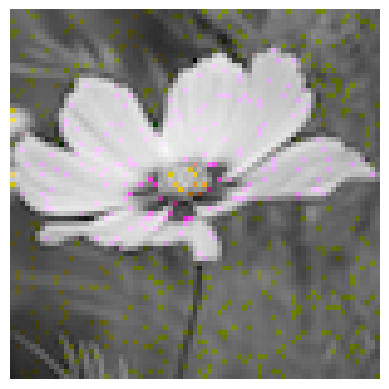

In [21]:
#read in image
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

img = mpimg.imread("figures/flower.png")
img = img[:,:,0:3]
m,n,_ = img.shape

np.random.seed(5)
random_numbers = np.random.rand(m,n)
known_ind = np.where(random_numbers >= 0.90)

# Very important as of 2025. Without this the solvers 
# declare the problem as primal infeasible due to numerics.
img = img.astype('float64')

# grayscale image
M = 0.299*img[:,:,0]+0.587*img[:,:,1]+0.114*img[:,:,2]
# known color values
print(img.shape)
R_known = img[:,:,0]
print(R_known.shape)
G_known = img[:,:,1]
B_known = img[:,:,2]
R_known = R_known[known_ind]
print(R_known.shape)
G_known = G_known[known_ind]
B_known = B_known[known_ind]

def save_img(filename, R,G,B):
   img = np.stack((np.array(R),np.array(G),np.array(B)), axis=2)
   plt.imshow(img)
   plt.axis('off')  # Turn off axis labels and ticks
   plt.gca().xaxis.set_major_locator(plt.NullLocator())  # Remove x-axis ticks
   plt.gca().yaxis.set_major_locator(plt.NullLocator())  # Remove y-axis ticks
    
   plt.savefig(filename, bbox_inches='tight', pad_inches=0)

R_given = np.copy(M)
R_given[known_ind] = R_known
G_given = np.copy(M)
G_given[known_ind] = G_known
B_given = np.copy(M)
B_given[known_ind] = B_known
save_img("flower_2025_given.png", R_given, G_given, B_given)

In [26]:
color_img = cp.Variable(img.shape)
obj620 = cp.Minimize(cp.tv(color_img[:,:,0], color_img[:,:,1], color_img[:,:,2]))
constr620 = [
        color_img[:,:,0][known_ind] == R_given[known_ind],
        color_img[:,:,1][known_ind] == G_given[known_ind],
        color_img[:,:,2][known_ind] == B_given[known_ind],
        M == 0.299*color_img[:,:,0]+0.587*color_img[:,:,1]+0.114*color_img[:,:,2]
    ]
prob620 = cp.Problem(obj620, constr620)
prob620.solve()

C:\Users\kyler\AppData\Local\Temp\ipykernel_90216\1725541404.py:10: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  prob620.solve()


np.float64(620.1011152806875)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19300404866659499..1.030978152968499].


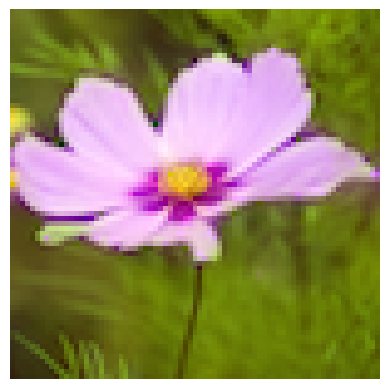

In [28]:
save_img("flower_2025_reconstructed.png", color_img.value[:,:,0], color_img.value[:,:,1], color_img.value[:,:,2])

### A7.39: Autoregressive process with Poisson conditionals

We setup the log-likelihood function:
$$ L(\nu, \omega) = log(\Pi_{i=1}^T Prob(X_i = x_i))  $$
$$ = \Sigma_{i=1}^T x_i log(\lambda_i) - \lambda_i - log(x_i!)  $$
$$ = \Sigma_{i=1}^T x_i log(\nu \omega^{x_{i-1}}) - \nu \omega^{x_{i-1}} - log(x_i!)
$$

Now we make the substitution $u = log(\nu), v = log(\omega) $. Thus $ \nu \omega^{x_{i-1}} = e^u e^{v x_{i-1}}$.  

Maximize
$$
 \Sigma_{i=1}^T x_i (u + vx_{i-1}) - e^{u + vx_{i-1}} 
 $$
for the variables u, v.

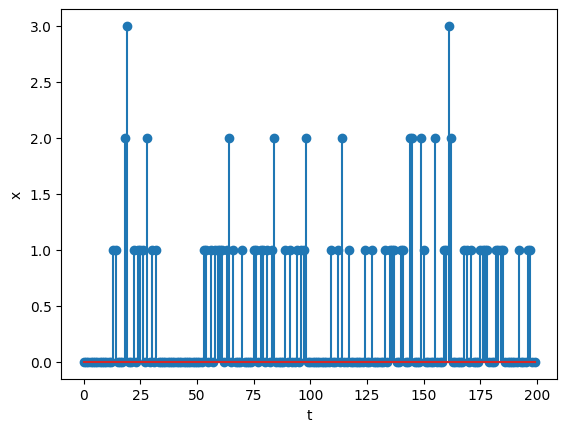

In [29]:
np.random.seed(1)
# Set initial values
num_points = 200
x = np.zeros(num_points)
lam = np.zeros(num_points)
nu = 0.3
omega = 1.5
lam[0] = nu
x[0] = np.random.poisson(lam[0])
# Generate values for x and update lambda
for t in range(1, num_points):
    lam[t] = nu*(omega**x[t-1])
    x[t] = np.random.poisson(lam[t])

def plot_x():
    """Helper function if you want to visualize x"""
    import matplotlib.pyplot as plt
    plt.stem(x)
    plt.xlabel('t')
    plt.ylabel('x')
    plt.show()

plot_x()

In [ ]:
x_prev = np.zeros(num_points)
x_prev[1:] = x[:-1]
u = cp.Variable()
v = cp.Variable()
obj739 = cp.Maximize(cp.sum(cp.multiply(x, u + v * x_prev) - cp.exp(u + v * x_prev)))
prob739 = cp.Problem(obj739)
prob739.solve()

np.float64(-155.60710428870544)

In [47]:
print("estimated nu: ", np.exp(u.value))
print("estimated omega: ", np.exp(v.value))

estimated nu:  0.3633722016396999
estimated omega:  1.3702105806866856


### A11.8: Standard form LP barrier method with infeasible start Newton method

In [81]:
def lp_acent_infeas(A, b, c, x0):

    alpha = 0.1
    beta = 0.5
    epsilon = 1e-5
    max_iters = 50

    m = b.size
    n = x0.size

    nu = np.zeros(m)
    x = x0

    residuals = []

    for i in range(max_iters):

        H = np.diag(x**-2)

        r_dual = c - x**-1 + A.T @ nu
        r_pri = A @ x - b

        r = np.append(r_dual, r_pri)

        r_norm = la.norm(r)
        residuals.append(r_norm)

        print(f"Iter {i}. Residual {r_norm:.6f}")

        if r_norm <= epsilon and la.norm(A @ x - b) <= epsilon:
            break

        X2 = np.diag(x**2)

        d_nu = la.solve(A @ X2 @ A.T,
                        r_pri - A @ (X2 @ r_dual))

        d_x = -X2 @ (r_dual + A.T @ d_nu)

        t = 1

        while np.min(x + t*d_x) <= 0:
            t *= beta

        r_dual_new = c - (x + t*d_x)**-1 + A.T @ (nu + t*d_nu)
        r_pri_new = A @ (x + t*d_x) - b

        while la.norm(np.append(r_dual_new, r_pri_new)) > (1-alpha*t)*r_norm:
            t *= beta
            r_dual_new = c - (x + t*d_x)**-1 + A.T @ (nu + t*d_nu)
            r_pri_new = A @ (x + t*d_x) - b

        x = x + t*d_x
        nu = nu + t*d_nu

    return (x, nu, i, np.array(residuals))

In [97]:
def barrier_lp(A, b, c, stop_crit = 10e-3, mu=10):
    m, n = A.shape
    num_centering_steps = 0
    t = 1
    history = []
    x_k = np.random.rand(n) + 0.5
    while True:
        num_centering_steps += 1
        d = t * c
        x_k, nu_k, iters, hist_k = lp_acent_infeas(A, b, d, x_k)
        history.append([iters+1, m/t])
        t *= mu
        if m / t <= stop_crit:
            break
    return x_k, nu_k, history

m = 100
n = 500
A = np.random.randn(m, n)
p = np.random.rand(n) + 1
b = A @ p
c = np.random.randn(n)

x, nu, history = barrier_lp(A, b, c)

Iter 0. Residual 140.271693
Iter 1. Residual 105.843640
Iter 2. Residual 55.278019
Iter 3. Residual 42.562840
Iter 4. Residual 37.896617
Iter 5. Residual 35.944434
Iter 6. Residual 35.062065
Iter 7. Residual 34.703930
Iter 8. Residual 34.676930
Iter 9. Residual 34.652876
Iter 10. Residual 34.646437
Iter 11. Residual 34.645604
Iter 12. Residual 34.645212
Iter 13. Residual 34.645185
Iter 14. Residual 34.645163
Iter 15. Residual 34.645163
Iter 16. Residual 34.645006
Iter 17. Residual 34.645004
Iter 18. Residual 34.645004
Iter 19. Residual 34.645004
Iter 20. Residual 34.645004
Iter 21. Residual 34.645004
Iter 22. Residual 34.645004
Iter 23. Residual 34.645004
Iter 24. Residual 34.645004
Iter 25. Residual 34.645004
Iter 26. Residual 34.645004
Iter 27. Residual 34.645004
Iter 28. Residual 34.645004
Iter 29. Residual 34.645004
Iter 30. Residual 34.645004
Iter 31. Residual 34.645004
Iter 32. Residual 34.645004
Iter 33. Residual 34.645004
Iter 34. Residual 34.645004
Iter 35. Residual 34.645004


In [98]:
history_np = np.array(history)

In [99]:
history

[[50, 100.0], [50, 10.0], [50, 1.0], [50, 0.1]]

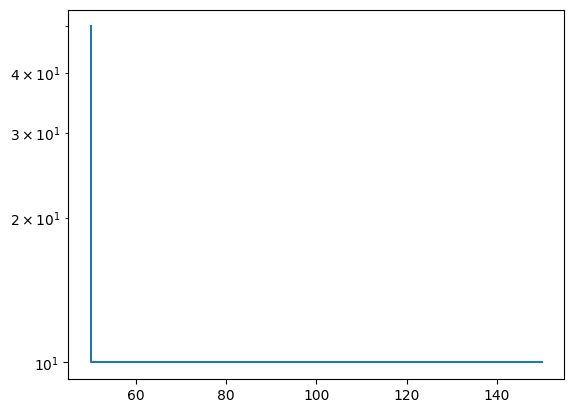

In [100]:
plt.step(np.cumsum(history_np[0,:]),history_np[1,:])
plt.yscale("log")
plt.show()

bruh

### A22.4: Moving obstacle avoidance

In [130]:
import cvxpy as cp
import dccp
# dimensions and data

T, h, m, dmin = 60, 0.05, 1, 0.07
S = 1 / ((T-1) * h)

ob_p0 = np.array([
    [0.40,  0.16],
    [0.34, -0.34],
    [0.00,  0.40],
    [1.00,  0.15]
])

ob_v = np.array([
    [-0.36, -0.34],
    [ 0.00,  0.30],
    [ 0.34, -0.17],
    [-0.38, -0.09]
])

num_obstacles = 4

obstacles = [p0 + np.arange(T)[:, None] * h * v for p0, v in zip(ob_p0, ob_v)]  # shape (4, T, 2)

f = cp.Variable((T, 2))
p = cp.Variable((T, 2))
v = cp.Variable((T, 2))

obj224 = cp.Minimize(cp.sum(cp.norm(f, axis=0)))
constr224 = [
    p[0] == (0, 0),
    p[T-1] == (1, 0),
    v[0] == (S, 0),
    v[T-1] == (S, 0),
]
#vehicle  + obstacle dynamics
for i in range(T-1):
    constr224 += [
        p[i+1] == p[i] + h * v[i],
        v[i+1] == v[i] + (h/m) * f[i]
    ]

for i in range(1, T):
    for j in range(num_obstacles):
        constr224 += [dmin - cp.norm(p[i] - obstacles[j][i, :]) <= 0]
        
prob224 = cp.Problem(obj224, constr224)
prob224.solve(method='dccp')

c:\Users\kyler\EE364A\.venv\Lib\site-packages\dccp\linearize.py:67: FutureWarning: 
    You didn't specify the order of the vec expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  cvx.vec(var - var.value), (var.shape[0] * var.shape[1], 1)
c:\Users\kyler\EE364A\.venv\Lib\site-packages\dccp\linearize.py:66: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  temp = cvx.reshape(
c:\Users\kyler\EE364A\.venv\Lib\site-packages\dccp\linearize.py:74: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVX

(np.float64(4.468680468807499),
 np.float64(1.525593514477191e-13),
 [array([[-0.13470281,  0.78289707],
         [-0.07745416,  0.62426629],
         [-0.02020571,  0.46563551],
         [ 0.03704249,  0.30700473],
         [ 0.09429039,  0.14837396],
         [ 0.15153793, -0.01025682],
         [ 0.20878501, -0.16888759],
         [ 0.26603154, -0.32751837],
         [ 0.32327737, -0.48614914],
         [ 0.38052249, -0.64477992],
         [ 0.3367949 , -0.64552593],
         [ 0.28672303, -0.5832741 ],
         [ 0.23665132, -0.52102228],
         [ 0.18657975, -0.45877047],
         [ 0.13650827, -0.39651865],
         [ 0.08643688, -0.33426684],
         [ 0.03636555, -0.27201503],
         [-0.01370583, -0.20976323],
         [-0.06377713, -0.14751144],
         [-0.11384794, -0.0852598 ],
         [-0.12156968,  0.02803661],
         [-0.12929166,  0.14133301],
         [-0.13701393,  0.25462941],
         [-0.14473831,  0.36792582],
         [-0.15246661,  0.48122225],
       

In [131]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# plot

def visualize(p, save=None):
    """
    Visualize a trajectory.
    
    Parameters
    ----------
    p : numpy.ndarray
        Position, shape (T, 2).
    save : str, optional
        Path to save the GIF.
    """
                
    for t in range(T):
        _, ax = plt.figure(figsize=(6, 6)), plt.gca() 
        for ob in obstacles:
            ax.add_artist(plt.Circle(ob[t], (2/3) * dmin, color='r'))
        ax.add_artist(plt.Circle(p[t], (1/3) * dmin, color='b'))
        ax.set_xticks([0, 0.5, 1])
        ax.set_xlim(-0.1, 1.1)
        ax.set_xlabel(r'$p_x$')
        ax.set_yticks([-0.5, 0, 0.5])
        ax.set_ylim(-0.6, 0.6)
        ax.set_ylabel(r'$p_y$')
        ax.set_aspect('equal')
        ax.set_title(f'$t = {t+1}$')
        plt.savefig(f'visualization_{t}.png')
        plt.close()

    gif_duration = 3
    frame_duration = int((gif_duration / T) * 1000)
    frames = []
    for t in range(T):
        file = f'visualization_{t}.png'
        if os.path.exists(file):
            frames.append(Image.open(file))
            #os.remove(file)

    output_path = 'visualization.gif' if save is None else save
    frames[0].save(
        output_path,
        save_all=True,
        append_images=frames[1:],
        duration=frame_duration,
        loop=0
    )
    print(f"GIF saved at {output_path}")

In [132]:
visualize(p.value)

GIF saved at visualization.gif


![alt text](visualization.gif)